In [23]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt 
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img , img_to_array


Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


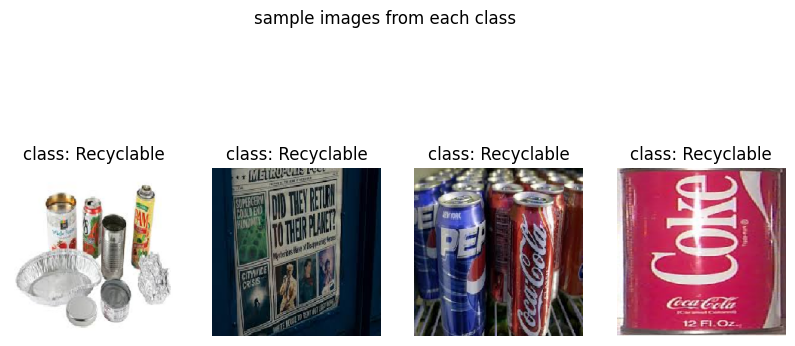

In [4]:
base_dir = r'C:\Users\sushm\OneDrive\Desktop\AI and Green technologies training program\archive (1)\DATASET'
train_dir = base_dir + r'\TRAIN'
test_dir = base_dir + r'\TEST'

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size = (224,224),
    batch_size = 32,
    class_mode ='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size = (224,224),
    batch_size=32,
    class_mode = 'binary'
)

plt.figure(figsize=(10,5))
for i  in range(4):
    image, label = next(train_data)
    plt.subplot(1,4,i+1)
    plt.imshow(image[0])
    plt.title("class: "+("Organic" if label[0] == 0 else "Recyclable"))
    plt.axis('off')

plt.suptitle("sample images from each class")
plt.show()

In [19]:
mobilenet_model = tf.keras.applications.MobileNetV2(input_shape=(224,224, 3) , include_top=False, weights='imagenet')
mobilenet_model.trainable = False

model = tf.keras.Sequential([
    mobilenet_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=2,
)
model.save('mobilenet_waste_classifier.h5')
loss, accuracy = model.evaluate(test_data)
print("Model Accuracy", accuracy)

Epoch 1/2
706/706 ━━━━━━━━━━━━━━━━━━━━ 570s 802ms/step - accuracy: 0.8574 - loss: 0.3281 - val_accuracy: 0.8766 - val_loss: 0.2738
Epoch 2/2
706/706 ━━━━━━━━━━━━━━━━━━━━ 357s 505ms/step - accuracy: 0.9323 - loss: 0.1745 - val_accuracy: 0.8687 - val_loss: 0.2942


79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 553ms/step - accuracy: 0.8646 - loss: 0.3044
Model Accuracy 0.868682861328125


In [22]:
from sklearn.metrics import classification_report , confusion_matrix
y_pred_prob = model.predict(test_data).flatten()
y_pred= (y_pred_prob>0.5).astype(int)
y_true = test_data.classes

print("Classification Report:\n", classification_report(y_true, y_pred , target_names=['Organic', 'Recyclable']))
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confussion Matrix:\n", conf_matrix)

79/79 ━━━━━━━━━━━━━━━━━━━━ 25s 313ms/step
Classification Report:
               precision    recall  f1-score   support

     Organic       0.55      0.66      0.60      1401
  Recyclable       0.43      0.33      0.37      1112

    accuracy                           0.51      2513
   macro avg       0.49      0.49      0.49      2513
weighted avg       0.50      0.51      0.50      2513

Confussion Matrix:
 [[922 479]
 [747 365]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


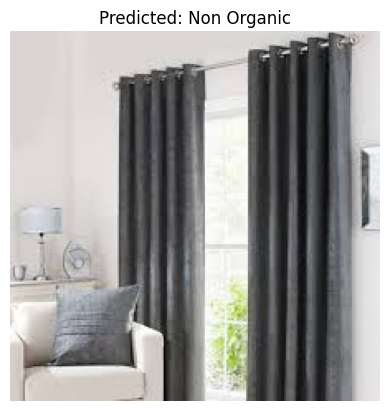

In [32]:
model_path = 'mobilenet_waste_classifier.h5'
test_image_path =r"C:\Users\sushm\OneDrive\Desktop\AI and Green technologies training program\archive (1)\DATASET\TEST\R\R_10072.jpg"

model = tf.keras.models.load_model(model_path)
test_img = load_img(test_image_path, target_size=(224,224))
test_img_array =img_to_array(test_img)/255.0
test_img_array = np.expand_dims(test_img_array, axis=0)

predicted_prob = model.predict(test_img_array)[0][0]
predicted_class = 'Organic' if predicted_prob < 0.5 else 'Non Organic'

plt.imshow(test_img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()
